# Set up

## Change working directory

In [1]:
%cd ../

C:\Users\Skylar\Downloads\tools


C:\Users\Skylar\Downloads\tools\env\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Install packages

In [2]:
# Placeholder

## Import development libraries

In [3]:
import hypothesis
import ipytest
import numpy as np
import pytest
from hypothesis import strategies as st
from pandera import pandas as pa
from sklearn import datasets as snds
from sklearn import ensemble as snee
from sklearn import model_selection as snmos
from tools import utils as tsus

ipytest.autoconfig(rewrite_asserts=False)

## Import other libraries

In [4]:
import itertools
import typing

import numpy as np
import pandas as pd
import toolz as tz
import tqdm
from matplotlib import pyplot as plt
from sklearn import base as snbe
from sklearn import feature_selection as snfs

## Declare constants

In [5]:
module: str = "feature_selection"

# Define QuasiConstantDropper

## Define

In [6]:
class QuasiConstantDropper(snbe.BaseEstimator, snbe.TransformerMixin):
    def __init__(self, drop_na: bool = False, threshold: float = 1e0) -> None:
        self.drop_na, self.threshold = drop_na, threshold

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "QuasiConstantDropper":
        self.most_frequent_percentages: pd.Series = self._get_most_frequent_percentages(data=X)
        self.constant_columns: pd.Index = self._get_constant_columns()
        self.remaining_columns: pd.Index = self._get_remaining_columns(data=X)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.drop(columns=self.constant_columns)

    def get_feature_names_out(self) -> list[str]:
        return self.remaining_columns.tolist()

    def _get_most_frequent_percentage(self, data: pd.Series) -> float:
        value_counts: pd.Series = data.value_counts(dropna=self.drop_na, normalize=True)
        return value_counts.iloc[0] if not value_counts.empty else 1e0

    def _get_most_frequent_percentages(self, data: pd.DataFrame) -> pd.Series:
        return data.apply(func=self._get_most_frequent_percentage).sort_values()

    def _get_percentages_above_threshold(self, data: pd.Series) -> pd.Series:
        return data[data.ge(other=self.threshold)]

    def _get_constant_columns(self) -> pd.Index:
        return self.most_frequent_percentages.pipe(func=self._get_percentages_above_threshold).index

    def _get_remaining_columns(self, data: pd.DataFrame) -> pd.Index:
        return data.columns.difference(other=self.constant_columns)

## Demonstrate

In [7]:
def join_numeric(data: pd.DataFrame) -> pd.DataFrame:
    numeric_data: pd.DataFrame = data.astype(dtype="category").apply(func=lambda x: x.cat.codes)
    return data.join(other=numeric_data, how="left", rsuffix="_numeric", validate="1:1")


# Create data
data: dict[str, list[str]] = {"constant": ["a"] * 5, "quasi_constant": ["a"] * 4 + ["b"], "not_constant": list("abcde")}
X = pd.DataFrame(data=data).pipe(func=join_numeric)
display(X)
# Loop through different thresholds
for threshold in [1e0, 8e-1]:  # type: float
    print("=" * int(8e1), "Threshold: %.1f" % threshold, "-" * int(8e1), sep="\n")
    display(QuasiConstantDropper(threshold=threshold).fit_transform(X=X))

,constant,quasi_constant,not_constant,constant_numeric,quasi_constant_numeric,not_constant_numeric
0,a,a,a,0,0,0
1,a,a,b,0,0,1
2,a,a,c,0,0,2
3,a,a,d,0,0,3
4,a,b,e,0,1,4


Threshold: 1.0
--------------------------------------------------------------------------------


,quasi_constant,not_constant,quasi_constant_numeric,not_constant_numeric
0,a,a,0,0
1,a,b,0,1
2,a,c,0,2
3,a,d,0,3
4,b,e,1,4


Threshold: 0.8
--------------------------------------------------------------------------------


,not_constant,not_constant_numeric
0,a,0
1,b,1
2,c,2
3,d,3
4,e,4


## Test

In [8]:
%%ipytest

# Helper(s)
columns: dict[str, pa.Column] = {
    "const": pa.Column(dtype=object, nullable=False, checks=pa.Check.isin(allowed_values=["a"])),
    "quasi": pa.Column(dtype=object, nullable=True),
    "all_nan": pa.Column(dtype=float, nullable=True, checks=pa.Check.isin(allowed_values=[None])),
}
X_strategy: st.SearchStrategy[pd.DataFrame] = pa.DataFrameSchema(columns=columns).strategy(size=5)

# Deterministic test(s)
@pytest.mark.parametrize('drop_na', [True, False])
def test_all_nan_column_droppped(drop_na: bool) -> None:
    X = pd.DataFrame(data={'a': range(1, 4), 'b': None})
    out: pd.DataFrame = QuasiConstantDropper().fit_transform(X=X)
    assert 'a' in out.columns
    assert 'b' not in out.columns

def test_threshold_edge_behavior() -> None:
    X = pd.DataFrame(data={'a': ['x'] * 3 + ['y']})
    out: pd.DataFrame = QuasiConstantDropper(threshold=7.5e-1).fit_transform(X=X)
    assert 'a' not in out.columns
    out: pd.DataFrame = QuasiConstantDropper(threshold=7.6e-1).fit_transform(X=X)
    assert 'a' in out.columns

# Property-based test(s)
@hypothesis.settings(deadline=None)
@hypothesis.given(X=X_strategy)
def test_quasi_constant_dropper(X: pd.DataFrame) -> None:
    dropper = QuasiConstantDropper()
    Xt: pd.DataFrame = dropper.fit_transform(X=X)
    # Property 1: Constant feature is always dropped
    assert "const" not in Xt.columns
    # Property 2: All NaN feature is always dropped
    assert "all_nan" not in Xt.columns

....                                                                                         [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define DuplicatedDropper

## Define

In [9]:
class DuplicatedDropper(snbe.BaseEstimator, snbe.TransformerMixin):
    def __init__(self, is_memory_low: bool = False) -> None:
        self.is_memory_low = is_memory_low

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "DuplicatedDropper":
        self.duplicated_columns: pd.Index = self._get_duplicated_columns(data=X)
        self.remaining_columns: pd.Index = self._get_remaining_columns(data=X)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.drop(columns=self.duplicated_columns)

    def get_feature_names_out(self) -> list[str]:
        return self.remaining_columns.tolist()

    def _get_duplicated_columns(self, data: pd.DataFrame) -> pd.Index:
        if self.is_memory_low:
            column_pairs: list[tuple[str, str]] = list(itertools.combinations(iterable=data.columns, r=2))
            duplicated_columns: list[str] = []
            for first_column, second_column in tqdm.tqdm(iterable=column_pairs):  # type: tuple[str, str]
                if data[first_column].equals(other=data[second_column]):
                    duplicated_columns.append(second_column)
            return pd.Index(data=duplicated_columns)
        else:
            return data.T.duplicated(keep="first").to_frame(name="flag").query(expr="flag").index

    def _get_remaining_columns(self, data: pd.DataFrame) -> pd.Index:
        return data.columns.difference(other=self.duplicated_columns)

## Demonstrate

In [10]:
# Create data
assign_args: dict[str, typing.Callable] = {
    "b": lambda x: x["a"],
    "c": lambda x: x["a"].sample(frac=1e0, random_state=0).values,
}
X = pd.DataFrame(data={"a": list("abcde")}).assign(**assign_args).pipe(func=join_numeric)
display(X)
# Transform
DuplicatedDropper().fit_transform(X=X)

,a,b,c,a_numeric,b_numeric,c_numeric
0,a,a,c,0,0,2
1,b,b,a,1,1,0
2,c,c,b,2,2,1
3,d,d,d,3,3,3
4,e,e,e,4,4,4


,a,c,a_numeric,c_numeric
0,a,c,0,2
1,b,a,1,0
2,c,b,2,1
3,d,d,3,3
4,e,e,4,4


## Test

In [11]:
%%ipytest

def test_equivalence() -> None:
    X = pd.DataFrame(data={"a": 1, "b": range(3), "c": range(3)})
    pd.testing.assert_frame_equal(
        left=DuplicatedDropper(is_memory_low=False).fit_transform(X=X), 
        right=DuplicatedDropper(is_memory_low=True).fit_transform(X=X)
    )

.                                                                                            [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define get_scores

## Define

In [12]:
def get_scores(rfecv: snfs.RFECV) -> pd.DataFrame:
    def flag_key(key: str) -> bool:
        return key.endswith("score") or key == "n_features"

    assign_args: dict[str, typing.Callable] = {
        "sem_test_score": lambda x: x.filter(regex=r"split\d+_test_score").sem(axis=1),
        "is_best": lambda x: x["mean_test_score"].pipe(func=lambda x: x.eq(other=x.max())),
        "best_mean": lambda x: x["mean_test_score"].where(cond=x["is_best"]).bfill().ffill(),
        "best_sem": lambda x: x["sem_test_score"].where(cond=x["is_best"]).bfill().ffill(),
        "best_lower": lambda x: x["best_mean"].sub(other=x["best_sem"]),
        "is_wi_1_sem": lambda x: x["mean_test_score"].ge(other=x["best_lower"]),
        "is_simplest_wi_1_sem": lambda x: x.index.__eq__(x.query(expr="is_wi_1_sem").index.min()),
    }
    return (
        tz.pipe(rfecv.cv_results_, tz.curried.keyfilter(flag_key), pd.DataFrame)
        .set_index(keys="n_features")
        .assign(**assign_args)
    )

## Demonstrate

In [13]:
def get_rfecv(is_classification: bool) -> snfs.RFECV:
    # Get estimator
    shared_args = dict(random_state=0)
    other_args = dict(class_weight="balanced_subsample") if is_classification else dict()
    random_forest_args = tz.merge(shared_args, other_args, dict(min_samples_leaf=1e-2, n_jobs=-1))
    RandomForest = snee.RandomForestClassifier if is_classification else snee.RandomForestRegressor
    random_forest = RandomForest(**random_forest_args)
    # Get cross-validator
    Splitter = snmos.StratifiedKFold if is_classification else snmos.KFold
    splitter = Splitter(shuffle=True, **shared_args)
    # Get RFECV
    return snfs.RFECV(estimator=random_forest, cv=splitter)


# Get data
X, y = data = snds.load_breast_cancer(return_X_y=True, as_frame=True)  # type: tuple[pd.DataFrame, pd.Series]
tsus.describe_structure(x=data)
# Split into train and test sets
X_train, X_test, y_train, y_test = splits = snmos.train_test_split(X, y, test_size=2e-1, stratify=y)  # type: list[pd.DataFrame | pd.Series]
tsus.describe_structure(x=splits)
# Initialize and fit model
rfecv = get_rfecv(is_classification=True)
rfecv.fit(X=X_train, y=y_train)
# Get scores
scores: pd.DataFrame = get_scores(rfecv=rfecv)
scores

<class 'tuple'> with 2 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (569, 30))
- element: 1
  (<class 'pandas.core.series.Series'>, (569,))
<class 'list'> with 4 elements
- element: 0
  (<class 'pandas.core.frame.DataFrame'>, (455, 30))
- element: 1
  (<class 'pandas.core.frame.DataFrame'>, (114, 30))
- element: 2
  (<class 'pandas.core.series.Series'>, (455,))
- element: 3
  (<class 'pandas.core.series.Series'>, (114,))


,mean_test_score,std_test_score,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,sem_test_score,is_best,best_mean,best_sem,best_lower,is_wi_1_sem,is_simplest_wi_1_sem
n_features,,,,,,,,,,,,,,
1,0.876923,0.029812,0.846154,0.868132,0.846154,0.912088,0.912088,0.014906,False,0.956044,0.009829,0.946215,False,False
2,0.923077,0.026917,0.901099,0.923077,0.890110,0.934066,0.967033,0.013459,False,0.956044,0.009829,0.946215,False,False
3,0.934066,0.030295,0.901099,0.934066,0.912088,0.934066,0.989011,0.015147,False,0.956044,0.009829,0.946215,False,False
4,0.934066,0.024076,0.912088,0.945055,0.901099,0.945055,0.967033,0.012038,False,0.956044,0.009829,0.946215,False,False
5,0.938462,0.023671,0.901099,0.956044,0.923077,0.945055,0.967033,0.011836,False,0.956044,0.009829,0.946215,False,False
6,0.938462,0.025631,0.901099,0.945055,0.923077,0.945055,0.978022,0.012815,False,0.956044,0.009829,0.946215,False,False
7,0.945055,0.025059,0.912088,0.945055,0.934066,0.945055,0.989011,0.012529,False,0.956044,0.009829,0.946215,False,False
8,0.951648,0.031544,0.912088,0.956044,0.923077,0.967033,1.000000,0.015772,False,0.956044,0.009829,0.946215,True,True
9,0.951648,0.029974,0.912088,0.945055,0.934066,0.967033,1.000000,0.014987,False,0.956044,0.009829,0.946215,True,False


## Test

In [14]:
%%ipytest

# Helper(s)
def make_data(is_classification: bool, n_features: int, n_informative_frac: float) -> tuple[pd.DataFrame, pd.Series]:
    make_fn: typing.Callable = snds.make_classification if is_classification else snds.make_regression
    n_informative: int = max(int(np.ceil(n_informative_frac * n_features)), 2)
    other_args = {"n_repeated": 1} if is_classification else {}
    X, y = data = make_fn(n_features=n_features, n_informative=n_informative, **other_args)  # type: tuple[np.ndarray, np.ndarray]
    return pd.DataFrame(data=X).rename(columns=str), pd.Series(data=y)

# Property-based test(s)
@pytest.mark.parametrize('is_classification', [False, True])
@pytest.mark.parametrize('n_features', [2**4, 2**5])
@pytest.mark.parametrize('n_informative_frac', np.arange(start=2e-1, stop=1, step=2e-1).tolist())
def test_get_scores(is_classification: bool, n_features: int, n_informative_frac: float) -> None:
    X, y = make_data(is_classification=is_classification, n_features=n_features, n_informative_frac=n_informative_frac) # type: tuple[pd.DataFrame, pd.Series]
    rfecv: snfs.RFECV = get_rfecv(is_classification=is_classification)
    rfecv.fit(X=X, y=y)
    scores: pd.DataFrame = get_scores(rfecv=rfecv)
    # Property 1: There are no NaNs
    assert scores.notna().all().all()
    # Property 2: Best row(s) anchor to best_mean and best_sem
    best_scores: pd.DataFrame = scores.query(expr="is_best")
    shared_args = dict(check_names=False)
    pd.testing.assert_series_equal(left=best_scores["best_mean"], right=best_scores["mean_test_score"], **shared_args)
    pd.testing.assert_series_equal(left=best_scores["best_sem"], right=best_scores["sem_test_score"], **shared_args)
    # Property 3: At least 1 model is within 1 SE
    assert scores['is_wi_1_sem'].any()

................                                                                             [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define plot_scores

## Define

In [15]:
def plot_scores(scores: pd.DataFrame, **kwargs) -> plt.Axes:
    # Get scores
    best_score: dict[int, float] = scores.query(expr="is_best")["mean_test_score"].to_dict()
    simplest_wi_1_sem_score: dict[int, float] = scores.query(expr="is_simplest_wi_1_sem")["mean_test_score"].to_dict()
    # Get title
    parts: list[str] = [
        "Best: %d features / %.3f score" % next(iter(best_score.items())),
        "Simplest w/i 1 SEM: %d features / %.3f score" % next(iter(simplest_wi_1_sem_score.items())),
    ]
    title: str = "\n".join(parts)
    # Plot error bars
    keys: list[str] = ["y", "yerr", "marker"]
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in keys, d=kwargs)
    shared_args = dict(y="mean_test_score")
    ax: plt.Axes = scores.plot(yerr="sem_test_score", marker=".", **filtered_kwargs, **shared_args)
    # Plot points
    shared_args.update(color="k", ax=ax)
    scores.query(expr="is_best").plot(marker="^", label="best", **shared_args)
    scores.query(expr="is_simplest_wi_1_sem").plot(marker="o", label="simplest", **shared_args)
    # Plot guide lines
    ax.axhline(y=scores["best_lower"].iloc[0], color="k", ls=":")
    list(map(lambda x: ax.axvline(x=next(iter(x)), c="k", ls=":"), [best_score, simplest_wi_1_sem_score]))
    # Set labels
    ax.set(ylabel="Mean +/- SEM", title=title)
    return ax

## Demonstrate

<Axes: title={'center': 'Best: 20 features / 0.956 score\nSimplest w/i 1 SEM: 8 features / 0.952 score'}, xlabel='n_features', ylabel='Mean +/- SEM'>

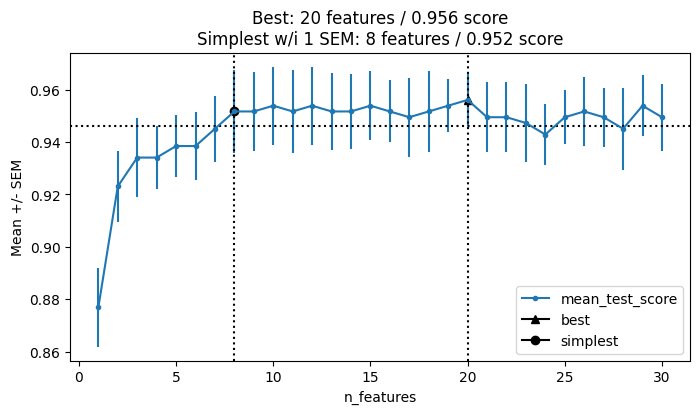

In [16]:
ax: plt.Axes = plt.subplot(1, 1, 1)
plot_scores(scores=scores, ax=ax, figsize=(8, 4))

## Test

In [17]:
# Placeholder

# Define get_support

## Define

In [18]:
def get_support(rfecv: snfs.RFECV) -> pd.DataFrame:
    def get_split_support(key: str, rfecv: snfs.RFECV = rfecv) -> pd.DataFrame:
        return (
            pd.DataFrame(data=rfecv.cv_results_[key], index=rfecv.cv_results_["n_features"])
            .apply(func=np.array, axis=1)
            .apply(func=lambda x: rfecv.feature_names_in_[x])
        )

    def get_frequencies(data: pd.DataFrame) -> pd.Series:
        return data.apply(func=tz.compose_left(tz.concat, tz.frequencies), axis=1)

    def get_intersections(data: pd.DataFrame) -> pd.Series:
        def flag_value(frequency: int, data: pd.DataFrame = data) -> bool:
            """Flag features selected in all splits (i.e., frequency == n_splits)"""
            return frequency == data.shape[1] - 1  # Get n_splits (support columns minus "frequencies" column)

        def get_intersection(frequencies: dict[str, int]) -> list[str]:
            return list(tz.valfilter(predicate=flag_value, d=frequencies))

        return data["frequencies"].apply(func=get_intersection)

    def get_intersection_percentage(data: pd.DataFrame) -> pd.Series:
        return data["intersection"].apply(func=len).div(other=data.index)

    support_keys: list[str] = tz.pipe(rfecv.cv_results_, tz.curried.keyfilter(lambda x: x.endswith("support")), list)
    assign_args: dict[str, typing.Callable] = {
        "frequencies": get_frequencies,
        "intersection": get_intersections,
        "intersection_percentage": get_intersection_percentage,
    }
    return (
        pd.concat(objs=map(get_split_support, support_keys), axis=1)
        .assign(**assign_args)
        .rename_axis(index="n_features")
    )

## Demonstrate

In [19]:
support: pd.DataFrame = get_support(rfecv=rfecv)
support

,0,1,2,3,4,frequencies,intersection,intersection_percentage
n_features,,,,,,,,
1,[mean concave points],[worst perimeter],[worst area],[worst perimeter],[worst perimeter],"{'mean concave points': 1, 'worst perimeter': ...",[],0.000000
2,"[mean concave points, worst perimeter]","[mean concave points, worst perimeter]","[worst perimeter, worst area]","[mean concave points, worst perimeter]","[mean concave points, worst perimeter]","{'mean concave points': 4, 'worst perimeter': ...",[worst perimeter],0.500000
3,"[mean concave points, worst perimeter, worst c...","[mean concave points, worst perimeter, worst c...","[worst perimeter, worst area, worst concave po...","[mean concave points, worst perimeter, worst c...","[mean concave points, worst perimeter, worst c...","{'mean concave points': 4, 'worst perimeter': ...","[worst perimeter, worst concave points]",0.666667
4,"[mean concave points, worst perimeter, worst a...","[mean concave points, worst perimeter, worst a...","[worst radius, worst perimeter, worst area, wo...","[mean concave points, worst perimeter, worst a...","[mean concave points, worst perimeter, worst a...","{'mean concave points': 4, 'worst perimeter': ...","[worst perimeter, worst area, worst concave po...",0.750000
5,"[mean concave points, worst radius, worst peri...","[mean concave points, worst radius, worst peri...","[mean concave points, worst radius, worst peri...","[mean concave points, worst radius, worst peri...","[mean concave points, worst radius, worst peri...","{'mean concave points': 5, 'worst radius': 5, ...","[mean concave points, worst radius, worst peri...",1.000000
6,"[mean concavity, mean concave points, worst ra...","[mean concavity, mean concave points, worst ra...","[mean concavity, mean concave points, worst ra...","[mean concavity, mean concave points, worst ra...","[mean concavity, mean concave points, worst ra...","{'mean concavity': 5, 'mean concave points': 5...","[mean concavity, mean concave points, worst ra...",1.000000
7,"[mean concavity, mean concave points, worst ra...","[mean perimeter, mean concavity, mean concave ...","[mean concavity, mean concave points, worst ra...","[mean concavity, mean concave points, worst ra...","[mean perimeter, mean concavity, mean concave ...","{'mean concavity': 5, 'mean concave points': 5...","[mean concavity, mean concave points, worst ra...",0.857143
8,"[mean radius, mean concavity, mean concave poi...","[mean perimeter, mean concavity, mean concave ...","[mean perimeter, mean concavity, mean concave ...","[mean texture, mean concavity, mean concave po...","[mean perimeter, mean concavity, mean concave ...","{'mean radius': 1, 'mean concavity': 5, 'mean ...","[mean concavity, mean concave points, worst ra...",0.750000
9,"[mean radius, mean perimeter, mean concavity, ...","[mean perimeter, mean area, mean concavity, me...","[mean perimeter, mean concavity, mean concave ...","[mean radius, mean texture, mean concavity, me...","[mean perimeter, mean area, mean concavity, me...","{'mean radius': 2, 'mean perimeter': 4, 'mean ...","[mean concavity, mean concave points, worst ra...",0.666667


## Test

In [20]:
%%ipytest

# Property-based test(s)
@pytest.mark.parametrize("is_classification", [False, True])
@pytest.mark.parametrize("n_features", [2**4, 2**5])
@pytest.mark.parametrize("n_informative_frac", np.arange(start=2e-1, stop=1, step=2e-1).tolist())
def test_get_support(is_classification: bool, n_features: int, n_informative_frac: float) -> None:
    X, y = make_data(is_classification=is_classification, n_features=n_features, n_informative_frac=n_informative_frac)  # type: tuple[pd.DataFrame, pd.Series]
    rfecv: snfs.RFECV = get_rfecv(is_classification=is_classification)
    rfecv.fit(X=X, y=y)
    support: pd.DataFrame = get_support(rfecv=rfecv)
    # Property 1: There are no NaNs
    assert support.notna().all().all()
    # Property 2: All support columns contain arrays of columns
    assert support.filter(regex="\d").map(func=lambda x: isinstance(x, np.ndarray)).all().all()
    # Property 3: All of these arrays have same length as number of features selected in each round
    assert support.filter(regex="\d").map(func=len).pipe(func=lambda x: x.eq(other=x.index.values[:, None])).all().all()
    # Property 4: Frequencies sum to number of features times number of splits
    pd.testing.assert_series_equal(
        left=support["frequencies"].apply(func=lambda x: sum(x.values())),
        right=support.filter(regex="\d").map(func=len).sum(axis=1),
        check_names=False,
    )
    # Property 5: Number of intersections is equal to number of features selected in all splits
    pd.testing.assert_series_equal(
        left=support["intersection"].apply(func=len),
        right=support["frequencies"].apply(func=tz.curried.valfilter(lambda x: x == rfecv.cv.n_splits)).apply(func=len),
        check_names=False,
    )
    # Property 6: Intersection percentage is equal to number of intersections / number of features
    pd.testing.assert_series_equal(
        left=support["intersection_percentage"],
        right=support["intersection"].apply(func=len).pipe(func=lambda x: x.div(other=x.index.values)),
        check_names=False,
    )

................                                                                             [100%]
======================================== warnings summary =========================================
env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; _hypothesis_globals
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; hypothesis
    self._mark_plugins_for_rewrite(hook, disable_autoload)

env\lib\site-packages\_pytest\config\__init__.py:1303
  C:\Users\Skylar\Downloads\tools\env\lib\site-packages\_pytest\config\__init__.py:1303: PytestAssertRewriteWarning: Module already imported so cannot be rew

# Define plot_support

## Define

In [21]:
def plot_support(support: pd.DataFrame, **kwargs) -> plt.Axes:
    column: str = "intersection_percentage"
    label: str = column.replace("_", " ").title()
    args = dict(marker=".", ylabel=label, title=label)
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in args, d=kwargs)
    ax: plt.Axes = support[column].plot(**args, **filtered_kwargs)
    return ax

## Demonstrate

<Axes: title={'center': 'Intersection Percentage'}, xlabel='n_features', ylabel='Intersection Percentage'>

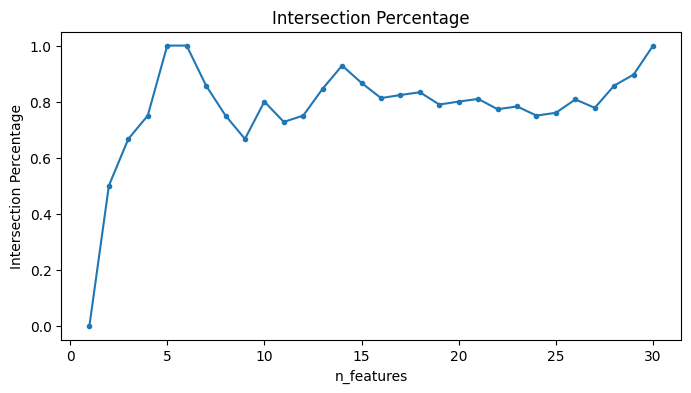

In [22]:
ax: plt.Axes = plt.subplot(1, 1, 1)
plot_support(support=support, ax=ax, figsize=(8, 4))

## Test

In [23]:
# Placeholder

# Write module

## Write

In [24]:
module_path: str = "src/tools/%s.py" % module

In [25]:
%%file $module_path

import itertools
import typing

import numpy as np
import pandas as pd
import toolz as tz
import tqdm
from matplotlib import pyplot as plt
from sklearn import base as snbe
from sklearn import feature_selection as snfs

class DuplicatedDropper(snbe.BaseEstimator, snbe.TransformerMixin):
    def __init__(self, is_memory_low: bool = False) -> None:
        self.is_memory_low = is_memory_low

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "DuplicatedDropper":
        self.duplicated_columns: pd.Index = self._get_duplicated_columns(data=X)
        self.remaining_columns: pd.Index = self._get_remaining_columns(data=X)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.drop(columns=self.duplicated_columns)

    def get_feature_names_out(self) -> list[str]:
        return self.remaining_columns.tolist()

    def _get_duplicated_columns(self, data: pd.DataFrame) -> pd.Index:
        if self.is_memory_low:
            column_pairs: list[tuple[str, str]] = list(itertools.combinations(iterable=data.columns, r=2))
            duplicated_columns: list[str] = []
            for first_column, second_column in tqdm.tqdm(iterable=column_pairs):  # type: tuple[str, str]
                if data[first_column].equals(other=data[second_column]):
                    duplicated_columns.append(second_column)
            return pd.Index(data=duplicated_columns)
        else:
            return data.T.duplicated(keep="first").to_frame(name="flag").query(expr="flag").index

    def _get_remaining_columns(self, data: pd.DataFrame) -> pd.Index:
        return data.columns.difference(other=self.duplicated_columns)

class QuasiConstantDropper(snbe.BaseEstimator, snbe.TransformerMixin):
    def __init__(self, drop_na: bool = False, threshold: float = 1e0) -> None:
        self.drop_na, self.threshold = drop_na, threshold

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "QuasiConstantDropper":
        self.most_frequent_percentages: pd.Series = self._get_most_frequent_percentages(data=X)
        self.constant_columns: pd.Index = self._get_constant_columns()
        self.remaining_columns: pd.Index = self._get_remaining_columns(data=X)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.drop(columns=self.constant_columns)

    def get_feature_names_out(self) -> list[str]:
        return self.remaining_columns.tolist()

    def _get_most_frequent_percentage(self, data: pd.Series) -> float:
        value_counts: pd.Series = data.value_counts(dropna=self.drop_na, normalize=True)
        return value_counts.iloc[0] if not value_counts.empty else 1e0

    def _get_most_frequent_percentages(self, data: pd.DataFrame) -> pd.Series:
        return data.apply(func=self._get_most_frequent_percentage).sort_values()

    def _get_percentages_above_threshold(self, data: pd.Series) -> pd.Series:
        return data[data.ge(other=self.threshold)]

    def _get_constant_columns(self) -> pd.Index:
        return self.most_frequent_percentages.pipe(func=self._get_percentages_above_threshold).index

    def _get_remaining_columns(self, data: pd.DataFrame) -> pd.Index:
        return data.columns.difference(other=self.constant_columns)

def get_scores(rfecv: snfs.RFECV) -> pd.DataFrame:
    def flag_key(key: str) -> bool:
        return key.endswith("score") or key == "n_features"

    assign_args: dict[str, typing.Callable] = {
        "sem_test_score": lambda x: x.filter(regex=r"split\d+_test_score").sem(axis=1),
        "is_best": lambda x: x["mean_test_score"].pipe(func=lambda x: x.eq(other=x.max())),
        "best_mean": lambda x: x["mean_test_score"].where(cond=x["is_best"]).bfill().ffill(),
        "best_sem": lambda x: x["sem_test_score"].where(cond=x["is_best"]).bfill().ffill(),
        "best_lower": lambda x: x["best_mean"].sub(other=x["best_sem"]),
        "is_wi_1_sem": lambda x: x["mean_test_score"].ge(other=x["best_lower"]),
        "is_simplest_wi_1_sem": lambda x: x.index.__eq__(x.query(expr="is_wi_1_sem").index.min()),
    }
    return (
        tz.pipe(rfecv.cv_results_, tz.curried.keyfilter(flag_key), pd.DataFrame)
        .set_index(keys="n_features")
        .assign(**assign_args)
    )

def get_support(rfecv: snfs.RFECV) -> pd.DataFrame:
    def get_split_support(key: str, rfecv: snfs.RFECV = rfecv) -> pd.DataFrame:
        return (
            pd.DataFrame(data=rfecv.cv_results_[key], index=rfecv.cv_results_["n_features"])
            .apply(func=np.array, axis=1)
            .apply(func=lambda x: rfecv.feature_names_in_[x])
        )

    def get_frequencies(data: pd.DataFrame) -> pd.Series:
        return data.apply(func=tz.compose_left(tz.concat, tz.frequencies), axis=1)

    def get_intersections(data: pd.DataFrame) -> pd.Series:
        def flag_value(frequency: int, data: pd.DataFrame = data) -> bool:
            """Flag features selected in all splits (i.e., frequency == n_splits)"""
            return frequency == data.shape[1] - 1  # Get n_splits (support columns minus "frequencies" column)

        def get_intersection(frequencies: dict[str, int]) -> list[str]:
            return list(tz.valfilter(predicate=flag_value, d=frequencies))

        return data["frequencies"].apply(func=get_intersection)

    def get_intersection_percentage(data: pd.DataFrame) -> pd.Series:
        return data["intersection"].apply(func=len).div(other=data.index)

    support_keys: list[str] = tz.pipe(rfecv.cv_results_, tz.curried.keyfilter(lambda x: x.endswith("support")), list)
    assign_args: dict[str, typing.Callable] = {
        "frequencies": get_frequencies,
        "intersection": get_intersections,
        "intersection_percentage": get_intersection_percentage,
    }
    return (
        pd.concat(objs=map(get_split_support, support_keys), axis=1)
        .assign(**assign_args)
        .rename_axis(index="n_features")
    )

def plot_scores(scores: pd.DataFrame, **kwargs) -> plt.Axes:
    # Get scores
    best_score: dict[int, float] = scores.query(expr="is_best")["mean_test_score"].to_dict()
    simplest_wi_1_sem_score: dict[int, float] = scores.query(expr="is_simplest_wi_1_sem")["mean_test_score"].to_dict()
    # Get title
    parts: list[str] = [
        "Best: %d features / %.3f score" % next(iter(best_score.items())),
        "Simplest w/i 1 SEM: %d features / %.3f score" % next(iter(simplest_wi_1_sem_score.items())),
    ]
    title: str = "\n".join(parts)
    # Plot error bars
    keys: list[str] = ["y", "yerr", "marker"]
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in keys, d=kwargs)
    shared_args = dict(y="mean_test_score")
    ax: plt.Axes = scores.plot(yerr="sem_test_score", marker=".", **filtered_kwargs, **shared_args)
    # Plot points
    shared_args.update(color="k", ax=ax)
    scores.query(expr="is_best").plot(marker="^", label="best", **shared_args)
    scores.query(expr="is_simplest_wi_1_sem").plot(marker="o", label="simplest", **shared_args)
    # Plot guide lines
    ax.axhline(y=scores["best_lower"].iloc[0], color="k", ls=":")
    list(map(lambda x: ax.axvline(x=next(iter(x)), c="k", ls=":"), [best_score, simplest_wi_1_sem_score]))
    # Set labels
    ax.set(ylabel="Mean +/- SEM", title=title)
    return ax

def plot_support(support: pd.DataFrame, **kwargs) -> plt.Axes:
    column: str = "intersection_percentage"
    label: str = column.replace("_", " ").title()
    args = dict(marker=".", ylabel=label, title=label)
    filtered_kwargs: dict[str, typing.Any] = tz.keyfilter(predicate=lambda x: x not in args, d=kwargs)
    ax: plt.Axes = support[column].plot(**args, **filtered_kwargs)
    return ax

Overwriting src/tools/feature_selection.py


## Format

In [26]:
!ruff format $module_path

1 file reformatted


## Check with ruff

In [27]:
!ruff check $module_path

ANN003 Missing type annotation for `**kwargs`
   --> src\tools\feature_selection.py:133:39
    |
133 | def plot_scores(scores: pd.DataFrame, **kwargs) -> plt.Axes:
    |                                       ^^^^^^^^
134 |     # Get scores
135 |     best_score: dict[int, float] = scores.query(expr="is_best")["mean_test_score"].to_dict()
    |

ANN003 Missing type annotation for `**kwargs`
   --> src\tools\feature_selection.py:160:41
    |
160 | def plot_support(support: pd.DataFrame, **kwargs) -> plt.Axes:
    |                                         ^^^^^^^^
161 |     column: str = "intersection_percentage"
162 |     label: str = column.replace("_", " ").title()
    |

Found 2 errors.


## Check with ty

In [28]:
!ty check $module_path

error[unresolved-attribute]: Object of type `RFECV` has no attribute `feature_names_in_`
   --> src\tools\feature_selection.py:101:35
    |
 99 |             pd.DataFrame(data=rfecv.cv_results_[key], index=rfecv.cv_results_["n_features"])
100 |             .apply(func=np.array, axis=1)
101 |             .apply(func=lambda x: rfecv.feature_names_in_[x])
    |                                   ^^^^^^^^^^^^^^^^^^^^^^^
102 |         )
    |
info: rule `unresolved-attribute` is enabled by default

Found 1 diagnostic
